# Import Library

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
!pip install pyvi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 56.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 62.6 MB/s eta 0:00:00


In [2]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.style as style
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns
import re
from pyvi import ViTokenizer
import string
import codecs
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report

In [3]:
train = pd.read_csv('/content/drive/MyDrive/HocMayUD/Shopee_Review/Data/train.csv')
validation = pd.read_csv('/content/drive/MyDrive/HocMayUD/Shopee_Review/Data/val.csv')

# Data Preprocessing

In [4]:
train[train['label'] == 0].head()

,text,label
0,sp tốt giao tầm tuần tại hàng qte,0
1,mn nên mua nha hình_ảnh mang tính_chất minh_hoạ,0
2,h h d d s s d d h s h d d s s h s h s s d d,0
3,đã nhận đx hàng dép đẹp giá rẻ nhưng về dép bị...,0
4,chất_liệu cao_su,0


In [5]:
train[train['label'] == 1].head()

,text,label
1469,sản_phẩm dùng ok shop giao hàng khá nhanh nhưn...,1
1470,đúng với mô tảk đc đúng lắm,1
1471,hơi nhỏ với mình nma vẫn gấc tuyệt nha a,1
1472,màu_sắc như hình,1
1473,chất_lượng sản_phẩm tốt,1


In [6]:
train.isnull().sum()

,0
text,0
label,0


In [7]:
validation.head()

,text,label
0,đúng với mô_tả đúng vs ảnh,0
1,tạm ổn,0
2,"túi giống với hình đăng , có đều kích_thước tú...",0
3,y y t x t cuc c t c x t d x t xtret t g g te e...,0
4,độ bền màu om m chưa test,0


In [8]:
validation.isnull().sum()

,0
text,0
label,0


In [9]:
train.shape

(3735, 2)

In [10]:
validation.shape

(416, 2)

In [11]:
train_texts = set(train['text'])
val_texts = set(validation['text'])

missing_in_train = val_texts.difference(train_texts)
print("Review chỉ có trong test:", missing_in_train)

Review chỉ có trong test: {'đẹp lắm m nha a mỗi_tội mới mua về có mùi cao_su hơi nồng', 'giao hàng cũng khá nhanh', 'vải hơi mỏng nhưng với giá tiền này thì hợp_lý', 'đại cùi nhưng anh shipper rất ok', 'được quá được được quá đ rất ổn nhưng_mà màu tai bị lấp_lánh khoong thể_nào tắt được', 'nên mua nha mn , mà dép màu trắng nên dễ dơ lắm', 'chất_lượng sản_phẩm cũng k tốt cho lắm', 'p ri c e qua lit y', 'chất lương ok', 'di s xi si x k x k x c k c k d k d k x h x x d d k k c k d x k x c bs i xid', 'đẹp đi vừa chân giao hàng nhanh nhưng hơi lỗi', 'e ve r y thin g is pe re c t chỉ có_điều cái ụp tai hơi nhỏ nên k thoải_mái lắm còn âm_thanh với đèn thì ổn nha', 'công_dụng ok', 'màu_sắc xanh sầu_riêng', 'áo đẹp hình thêu sắc nét , hơi nhiều chỉ thừ a , hình_ảnh chỉ mang tc nhận xu', 'với giá tiền này thì ok', 'cũng được', 'loa nhỏ âm_thanh to', 'chất_liệu vải thoáng', 'mang ok', 'đúng với mô_tả đúng thực_tế', 'ổn', 'rẻ', 'giao hang nhanh', 'dss', 'chất_liệu tốt dày', 'ở ân_thi ai cần tìm việ

In [ ]:
# clean text
def clean_text(text):
  # convert to lowercase
  text = text.lower()

  # remove URL
  text = re.sub(r"http\S+", "", text)

  # remove mention (@)
  text = re.sub(r"@\S+", "", text)

  # remove hashtag
  text = re.sub(r"#\S+", "", text)

  # remove number
  text = re.sub(r"\d+", "", text)

  # remove special character
  text = re.sub(r"[^a-zA-ZÀ-ỹ\s]", " ", text)

  # standardize whitespace
  text = re.sub(r"\s+", " ", text).strip()

  return text

In [13]:
train['text'] = train['text'].apply(clean_text)
validation['text'] = validation['text'].apply(clean_text)

In [14]:
train.head()

,text,label
0,sp tốt giao tầm tuần tại hàng qte,0
1,mn nên mua nha hình ảnh mang tính chất minh hoạ,0
2,h h d d s s d d h s h d d s s h s h s s d d,0
3,đã nhận đx hàng dép đẹp giá rẻ nhưng về dép bị...,0
4,chất liệu cao su,0


In [15]:
def create_stopwordlist():
    f = codecs.open('/content/drive/MyDrive/HocMayUD/Shopee_Review/vietnamese-stopwords.txt', encoding='utf-8')
    data = []
    null_data = []
    for i, line in enumerate(f):
        line = repr(line)
        line = line[1:len(line)-3]
        data.append(line)
    return data

In [16]:
stopword_vn = create_stopwordlist()

In [17]:
def tokenize(text):
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = ViTokenizer.tokenize(text.lower())
    return [word for word in text.split() if word not in stopword_vn]

In [18]:
train['text'] = train['text'].apply(tokenize)
validation['text'] = validation['text'].apply(tokenize)

In [19]:
train['text'].head()

,text
0,"[sp, giao, tầm, tuần, hàng, qte]"
1,"[mn, mua, nha, hình_ảnh, tính_chất, minh_hoạ]"
2,"[h_h, d, d, s, s, d, d, h, s, h, d, d, s, s, h..."
3,"[đx, hàng, dép, đẹp, giá, rẻ, dép, móp, méo, đ..."
4,"[chất_liệu, cao_su]"


In [20]:
train['text'] = train['text'].apply(' '.join)
validation['text'] = validation['text'].apply(' '.join)

In [22]:
print(train['label'].value_counts())

label
1    2266
0    1469
Name: count, dtype: int64


# EDA - Explory data analysis

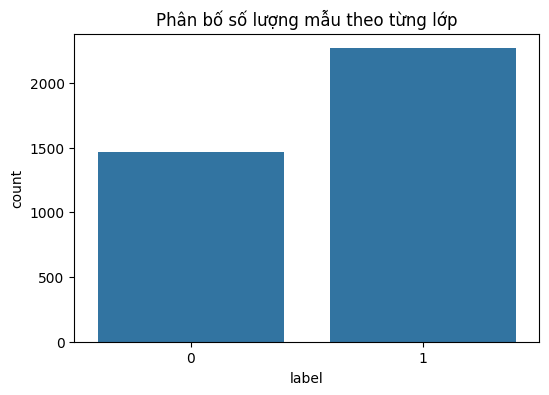

In [ ]:
# Draw bar chart
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=train)
plt.title("Phân bố số lượng mẫu theo từng lớp")
plt.show()

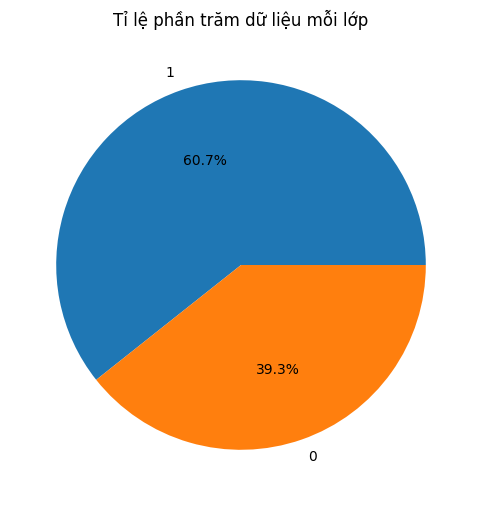

In [ ]:
# Draw percentage chart
train['label'].value_counts(normalize=True).plot(kind='pie', autopct='%1.1f%%', figsize=(6,6))
plt.title("Tỉ lệ phần trăm dữ liệu mỗi lớp")
plt.ylabel("")
plt.show()

# Vectorize TF-IDF

In [25]:
tfidf = TfidfVectorizer()
y_train = train.label.values
y_val = validation.label.values
X_train = tfidf.fit_transform(train['text'])
X_val = tfidf.transform(validation['text'])

# Training

In [26]:
svc = SVC(kernel='linear')

In [27]:
svc.fit(X_train, y_train)

SVC(kernel='linear')

In [29]:
from joblib import dump
dump(svc, '/content/drive/MyDrive/HocMayUD/Shopee_Review/svc_shopee.pkl')
dump(tfidf, '/content/drive/MyDrive/HocMayUD/Shopee_Review/tfidf_vectorizer.pkl')

['/content/drive/MyDrive/HocMayUD/Shopee_Review/tfidf_vectorizer.pkl']

# Evaluation

In [30]:
y_pred = svc.predict(X_val)
cfs = confusion_matrix(y_val, y_pred)

print("Ma trận nhầm lẫn")
print(cfs)

clr = classification_report(y_val, y_pred)
print('-'*100)
print(clr)

Ma trận nhầm lẫn
[[106  58]
 [ 34 218]]
----------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.76      0.65      0.70       164
           1       0.79      0.87      0.83       252

    accuracy                           0.78       416
   macro avg       0.77      0.76      0.76       416
weighted avg       0.78      0.78      0.78       416



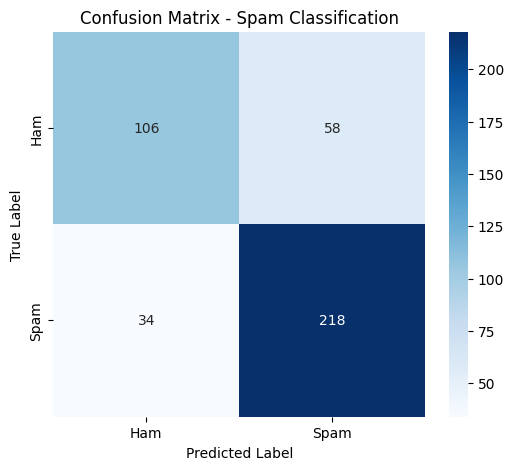

In [31]:
y_pred = svc.predict(X_val)

#confusion matrix
cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Ham", "Spam"], yticklabels=["Ham", "Spam"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Spam Classification")
plt.show()


# Deployment

In [32]:
from joblib import load

model = load('/content/drive/MyDrive/HocMayUD/Shopee_Review/svc_shopee.pkl')
tfidf = load('/content/drive/MyDrive/HocMayUD/Shopee_Review/tfidf_vectorizer.pkl')

In [ ]:
import gradio as gr
def predict_sentiment(text):
    text = clean_text(text)
    vector = tfidf.transform([text])
    pred = model.predict(vector)
    return "Positive" if pred[0] == 1 else "Negative"

# Gradio interface
demo = gr.Interface(
    fn=predict_sentiment,
    inputs=gr.Textbox(lines=3, placeholder="Enter a Shopee review here..."),
    outputs="text",
    title="Shopee Review Sentiment Analysis",
    description="This app predicts sentiment (Positive, Negative) for Shopee product reviews."
)

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://53728f11539e1eb13e.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
